In [1]:
import pandas as pd
from datasets import load_dataset
dataset=load_dataset("cardiffnlp/tweet_eval", "sentiment")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [2]:
df= dataset["train"].to_pandas()
print(df.head())

                                                text  label
0  "QT @user In the original draft of the 7th boo...      2
1  "Ben Smith / Smith (concussion) remains out of...      1
2  Sorry bout the stream last night I crashed out...      1
3  Chase Headley's RBI double in the 8th inning o...      1
4  @user Alciato: Bee will invest 150 million in ...      2


In [3]:
print(df.shape)

(45615, 2)


In [4]:
print(df.head(10))

                                                text  label
0  "QT @user In the original draft of the 7th boo...      2
1  "Ben Smith / Smith (concussion) remains out of...      1
2  Sorry bout the stream last night I crashed out...      1
3  Chase Headley's RBI double in the 8th inning o...      1
4  @user Alciato: Bee will invest 150 million in ...      2
5  @user LIT MY MUM 'Kerry the louboutins I wonde...      2
6  "\"""" SOUL TRAIN\"""" OCT 27 HALLOWEEN SPECIA...      2
7  So disappointed in wwe summerslam! I want to s...      0
8  "This is the last Sunday w/o football .....,NF...      2
9  @user @user CENA & AJ sitting in a tree K-I-S-...      1


In [5]:
print(dataset["train"].features)

{'text': Value('string'), 'label': ClassLabel(names=['negative', 'neutral', 'positive'])}


In [6]:
df["label"].value_counts()

label
1    20673
2    17849
0     7093
Name: count, dtype: int64

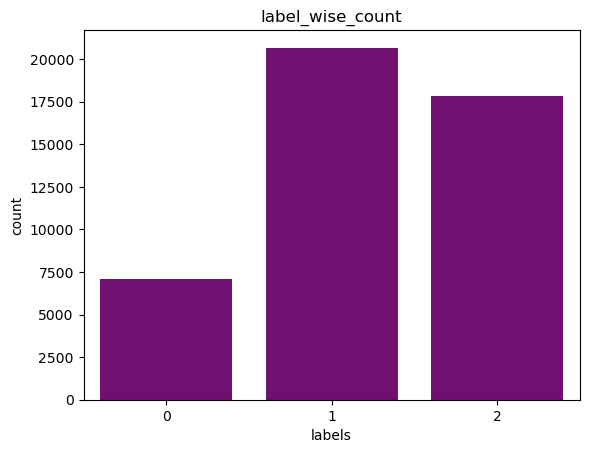

In [7]:
import seaborn as sb
import matplotlib.pyplot as plt
sb.countplot(df, x=df['label'], color='purple')
plt.title('label_wise_count')
plt.xlabel('labels')
plt.ylabel('count')
plt.show()

In [8]:
from sklearn.model_selection import train_test_split 
x_train,x_test,y_train,y_test = train_test_split(df['text'],df['label'],test_size=0.2,random_state=42)


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer 
vectorizer = TfidfVectorizer(max_features=10000)
x_train_tfidf = vectorizer.fit_transform(x_train)
x_test_tfidf = vectorizer.transform(x_test)

In [28]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(x_train_tfidf,y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [29]:
model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
model_balanced.fit(x_train_tfidf, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [30]:
from sklearn.metrics import accuracy_score 
y_pred = model.predict(x_test_tfidf)
print("tfidf : " ,accuracy_score(y_test,y_pred))
y_pred_balanced = model_balanced.predict(x_test_tfidf)
print("balanced : " ,accuracy_score(y_test,y_pred_balanced))

tfidf :  0.6576783952647156
balanced :  0.6492381891921517


In [12]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=["Negative", "Neutral", "Positive"]))

              precision    recall  f1-score   support

    Negative       0.60      0.34      0.44      1379
     Neutral       0.63      0.76      0.69      4112
    Positive       0.71      0.67      0.69      3632

    accuracy                           0.66      9123
   macro avg       0.65      0.59      0.60      9123
weighted avg       0.66      0.66      0.65      9123



In [31]:
print(classification_report(y_test, y_pred_balanced, target_names=["Negative", "Neutral", "Positive"]))

              precision    recall  f1-score   support

    Negative       0.47      0.65      0.54      1379
     Neutral       0.68      0.63      0.65      4112
    Positive       0.72      0.67      0.69      3632

    accuracy                           0.65      9123
   macro avg       0.62      0.65      0.63      9123
weighted avg       0.66      0.65      0.65      9123



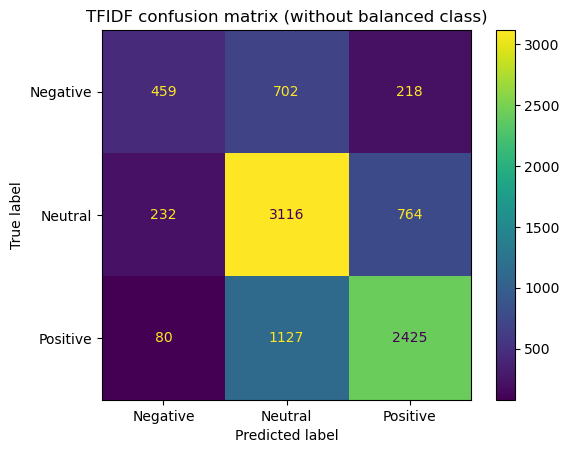

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay , confusion_matrix
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Negative","Neutral","Positive"])
disp.plot()
plt.title('TFIDF confusion matrix (without balanced class)')
plt.show()


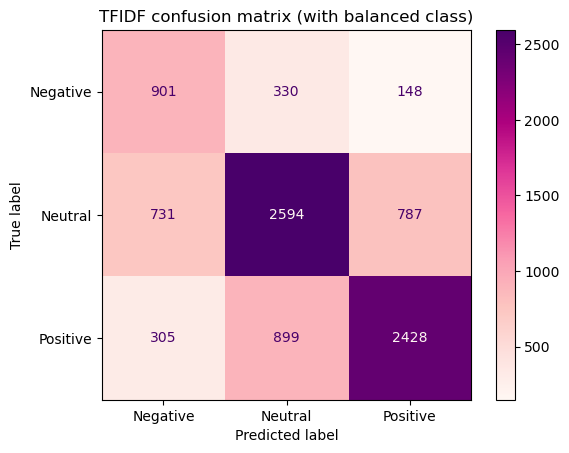

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay , confusion_matrix
cm = confusion_matrix(y_test,y_pred_balanced)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Negative","Neutral","Positive"])
disp.plot(cmap="RdPu")
plt.title('TFIDF confusion matrix (with balanced class)')
plt.show()


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer 
vectorizer = TfidfVectorizer(max_features=5000)
x_train_tfidf = vectorizer.fit_transform(x_train)
x_test_tfidf = vectorizer.transform(x_test)

In [15]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(x_train_tfidf,y_train)



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [16]:
from sklearn.metrics import accuracy_score 
y_pred = model.predict(x_test_tfidf)
print(accuracy_score(y_test,y_pred))

0.6557053600789214


In [17]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=["Negative", "Neutral", "Positive"]))

              precision    recall  f1-score   support

    Negative       0.59      0.35      0.44      1379
     Neutral       0.63      0.76      0.69      4112
    Positive       0.71      0.66      0.68      3632

    accuracy                           0.66      9123
   macro avg       0.64      0.59      0.60      9123
weighted avg       0.66      0.66      0.65      9123



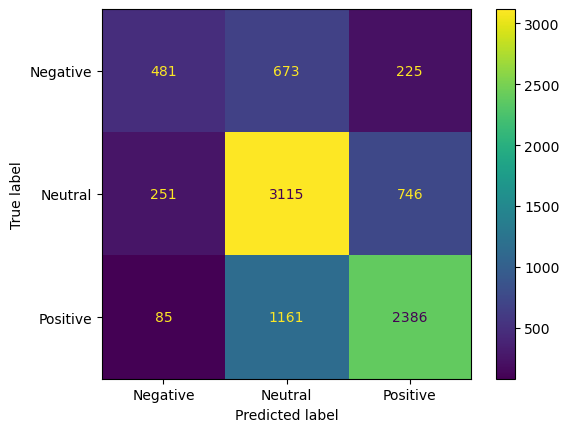

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay , confusion_matrix
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Negative","Neutral","Positive"])
disp.plot()
plt.show()


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer 
vectorizer = TfidfVectorizer(max_features=50000)
x_train_tfidf = vectorizer.fit_transform(x_train)
x_test_tfidf = vectorizer.transform(x_test)

In [20]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(x_train_tfidf,y_train)



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [21]:
from sklearn.metrics import accuracy_score 
y_pred = model.predict(x_test_tfidf)
print(accuracy_score(y_test,y_pred))

0.6576783952647156


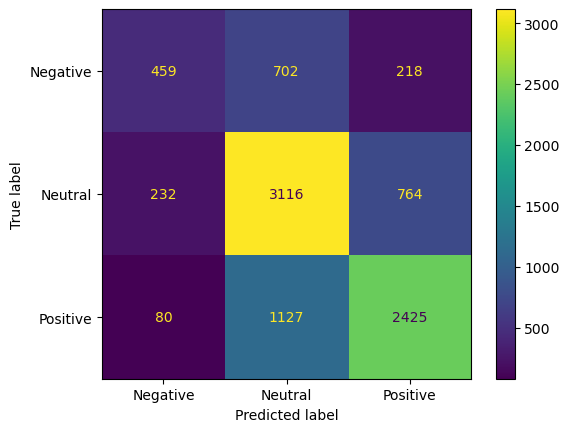

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay , confusion_matrix
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Negative","Neutral","Positive"])
disp.plot()
plt.show()


In [23]:
feature_names = vectorizer.get_feature_names_out()

In [24]:
print(model.coef_.shape)

(3, 38246)


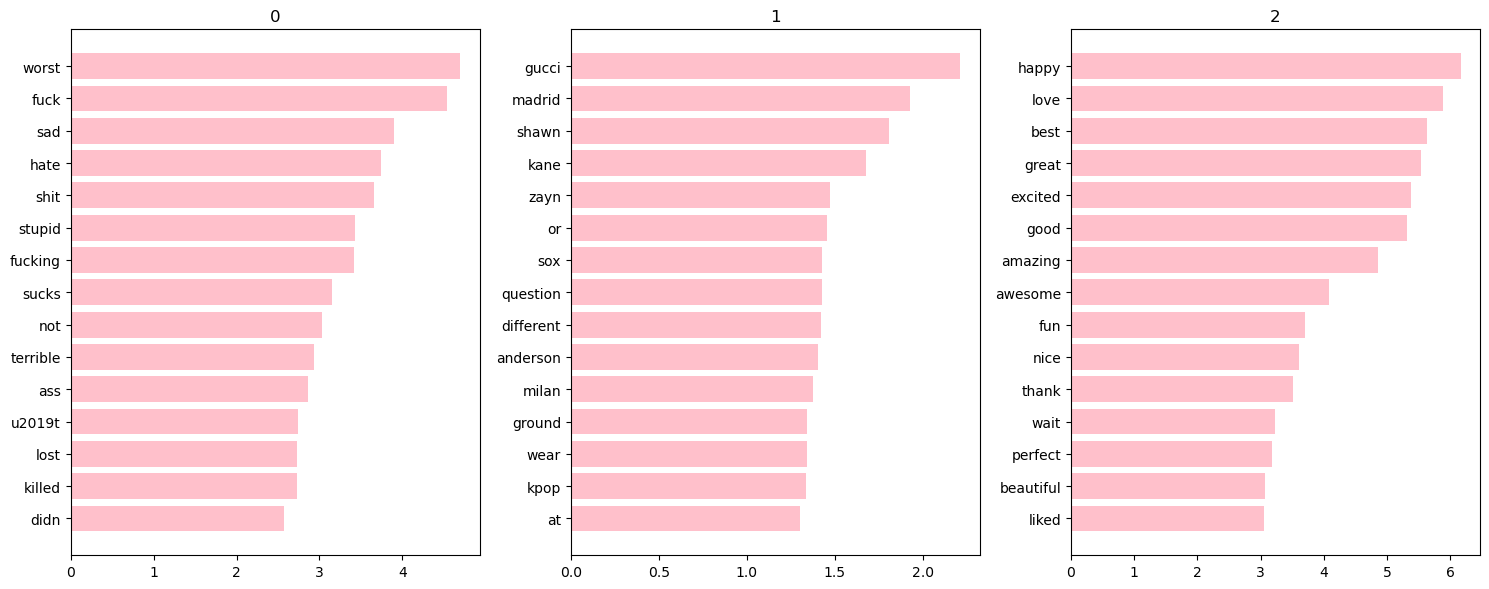

In [25]:
plt.figure(figsize=(15, 6))
classes = [0,1,2]
for i in classes :
    curr=model.coef_[i]
    top_indices=curr.argsort()[-15:]
    name=feature_names[top_indices]
    plt.subplot(1, 3, i+1)
    plt.barh(name, curr[top_indices],color='pink')
    plt.title(i)
plt.tight_layout()
plt.show()   

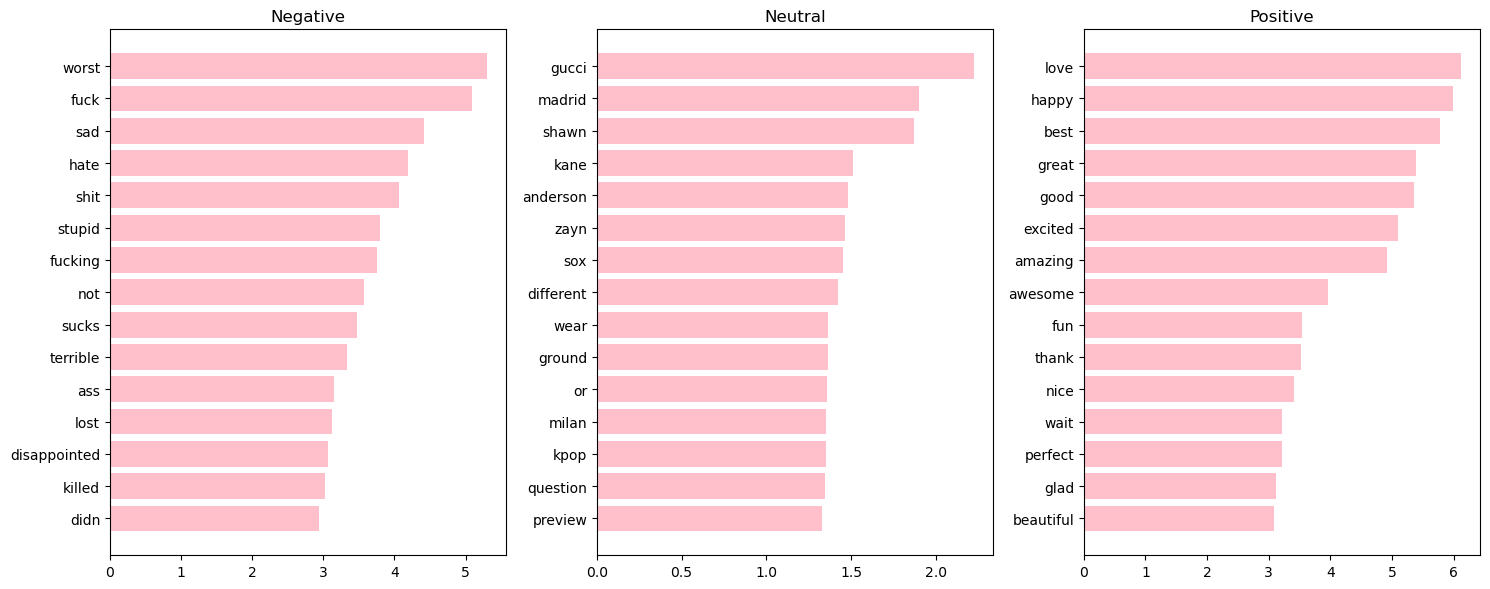

Despite improved Negative F1 scores, the top TF-IDF features per class remained largely unchanged between balanced and unbalanced models, suggesting class weighting affects decision boundaries rather than feature importance.


In [38]:
plt.figure(figsize=(15, 6))
classes = [0,1,2]
for i in classes:
    curr = model_balanced.coef_[i]
    top_indices = curr.argsort()[-15:]
    name = feature_names[top_indices]
    plt.subplot(1, 3, i+1)
    plt.barh(name, curr[top_indices], color='pink')
    plt.title(["Negative", "Neutral", "Positive"][i])
plt.tight_layout()
plt.show()
print('Despite improved Negative F1 scores, the top TF-IDF features per class remained largely unchanged between balanced and unbalanced models, suggesting class weighting affects decision boundaries rather than feature importance.')